In [21]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation, NMF

nltk.download("stopwords")
nltk.download("wordnet")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [23]:
file_path = "/complaints.csv"

complaints_raw = pd.read_csv(
    file_path,
    low_memory=False
)

complaints_raw.head()

,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Consumer consent provided?,Submitted via,Date sent to company,Company response to consumer,Timely response?,Consumer disputed?,Complaint ID
0,2022-11-19,"Credit reporting, credit repair services, or o...",Credit reporting,Improper use of your report,Reporting company used your report improperly,NaN,NaN,"EQUIFAX, INC.",TX,78541,Servicemember,NaN,Web,2022-11-19,In progress,Yes,NaN,6222374.0
1,2022-10-13,"Credit reporting, credit repair services, or o...",Credit reporting,Improper use of your report,Reporting company used your report improperly,In accordance with the fair credit reporting a...,Company has responded to the consumer and the ...,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",GA,30043,NaN,Consent provided,Web,2022-10-13,Closed with explanation,Yes,NaN,6079679.0
2,2022-10-13,"Credit reporting, credit repair services, or o...",Credit reporting,Incorrect information on your report,Information belongs to someone else,This is not a duplicate nor is this complaint ...,Company has responded to the consumer and the ...,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",CA,90660,NaN,Consent provided,Web,2022-10-13,Closed with non-monetary relief,Yes,NaN,6076990.0
3,2022-10-12,"Credit reporting, credit repair services, or o...",Credit reporting,Incorrect information on your report,Personal information incorrect,NaN,Company has responded to the consumer and the ...,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",PA,19148,NaN,Consent not provided,Web,2022-10-12,Closed with non-monetary relief,Yes,NaN,6080312.0
4,2022-11-19,"Credit reporting, credit repair services, or o...",Credit reporting,Incorrect information on your report,Information belongs to someone else,NaN,NaN,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",OH,44130,NaN,NaN,Web,2022-11-19,In progress,Yes,NaN,6222634.0


In [24]:
print("Rows and columns:", complaints_raw.shape)

print("\nColumn names:")
print(complaints_raw.columns.tolist())

complaints_raw.info()

Rows and columns: (121754, 18)

Column names:
['Date received', 'Product', 'Sub-product', 'Issue', 'Sub-issue', 'Consumer complaint narrative', 'Company public response', 'Company', 'State', 'ZIP code', 'Tags', 'Consumer consent provided?', 'Submitted via', 'Date sent to company', 'Company response to consumer', 'Timely response?', 'Consumer disputed?', 'Complaint ID']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 121754 entries, 0 to 121753
Data columns (total 18 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   Date received                 121754 non-null  object 
 1   Product                       121754 non-null  object 
 2   Sub-product                   120670 non-null  object 
 3   Issue                         121754 non-null  object 
 4   Sub-issue                     113639 non-null  object 
 5   Consumer complaint narrative  32903 non-null   object 
 6   Company public response       47

In [25]:
print(complaints_raw.shape)
print(complaints_raw["Consumer complaint narrative"].notna().sum())

(121754, 18)
32903


In [27]:
text_col = "Consumer complaint narrative"

complaints = complaints_raw[[text_col]].copy()

complaints = complaints.dropna()
complaints = complaints.drop_duplicates()
complaints = complaints.sample(n=min(30000, len(complaints)), random_state=10)

print("Remaining complaints:", len(complaints))

complaints.head()

Remaining complaints: 29425


,Consumer complaint narrative
56832,The accounts were unknown to me. I came across...
87032,"In XXXX of XXXX, I reached out to the XXXX maj..."
86145,It occurs that my credit report has been compr...
108904,The investigation of my discharged bankruptcy ...
103407,I disputed an error recently found on my Exper...


In [28]:
english_stopwords = set(stopwords.words("english"))
word_cleaner = WordNetLemmatizer()

def prepare_complaint_text(sentence):
    sentence = str(sentence).lower()
    sentence = re.sub(r"[^a-zA-Z\s]", " ", sentence)
    sentence = re.sub(r"\s+", " ", sentence).strip()

    tokens = sentence.split()

    useful_tokens = []

    for token in tokens:
        if token not in english_stopwords and len(token) > 2:
            useful_tokens.append(word_cleaner.lemmatize(token))

    return " ".join(useful_tokens)

In [29]:
complaints["clean_complaint"] = complaints[text_col].apply(prepare_complaint_text)

complaints = complaints[complaints["clean_complaint"].str.len() > 20]

complaints[[text_col, "clean_complaint"]].head()

,Consumer complaint narrative,clean_complaint
56832,The accounts were unknown to me. I came across...,account unknown came across law today accordin...
87032,"In XXXX of XXXX, I reached out to the XXXX maj...",xxxx xxxx reached xxxx major credit bureau tra...
86145,It occurs that my credit report has been compr...,occurs credit report compromised going file no...
108904,The investigation of my discharged bankruptcy ...,investigation discharged bankruptcy unauthoriz...
103407,I disputed an error recently found on my Exper...,disputed error recently found experian credit ...


In [30]:
word_count_vectorizer = CountVectorizer(
    max_features=1200,
    min_df=5,
    max_df=0.85
)

word_count_matrix = word_count_vectorizer.fit_transform(complaints["clean_complaint"])

print("Word Count Matrix:", word_count_matrix.shape)

Word Count Matrix: (29400, 1200)


In [31]:
importance_vectorizer = TfidfVectorizer(
    max_features=1200,
    min_df=5,
    max_df=0.85
)

tfidf_matrix = importance_vectorizer.fit_transform(complaints["clean_complaint"])

print("TF-IDF Matrix:", tfidf_matrix.shape)

TF-IDF Matrix: (29400, 1200)


In [32]:
def show_topic_words(model, vocabulary, top_n=10):
    for number, topic in enumerate(model.components_, start=1):
        strongest_words = topic.argsort()[-top_n:][::-1]
        words = [vocabulary[i] for i in strongest_words]
        print(f"Topic {number}: {', '.join(words)}")

In [33]:
lda_matrix = word_count_matrix

In [34]:
lda_topics = LatentDirichletAllocation(
    n_components=5,
    random_state=10,
    learning_method="online",
    max_iter=3,
    batch_size=64
)

lda_topics.fit(lda_matrix)

count_vocabulary = word_count_vectorizer.get_feature_names_out()

print("LDA topics:")
show_topic_words(lda_topics, count_vocabulary)

LDA topics:
Topic 1: payment, loan, credit, late, paid, mortgage, account, month, due, balance
Topic 2: account, bank, card, told, would, called, call, time, money, back
Topic 3: debt, information, consumer, collection, company, letter, provide, request, violation, credit
Topic 4: account, consumer, section, reporting, right, state, credit, agency, violated, privacy
Topic 5: credit, report, account, information, reporting, balance, date, xxxxxxxx, please, inquiry


In [35]:
nmf_topics = NMF(
    n_components=5,
    random_state=10,
    init="nndsvda",
    max_iter=400
)

nmf_topics.fit(tfidf_matrix)

tfidf_vocabulary = importance_vectorizer.get_feature_names_out()

print("NMF topics:")
show_topic_words(nmf_topics, tfidf_vocabulary)

NMF topics:
Topic 1: section, state, right, reporting, account, violated, consumer, privacy, furnish, accordance
Topic 2: report, credit, information, consumer, account, reporting, inquiry, bureau, inaccurate, usc
Topic 3: payment, account, bank, card, loan, would, told, called, time, money
Topic 4: score, transunion, fico, low, attempting, debt, causing, refused, credit, record
Topic 5: balance, xxxxxxxx, theft, identity, opened, item, complaint, block, date, remove


In [36]:
print("Comparison:")
print("CountVectorizer better for LDA because it uses word frequency.")
print("TF-IDF good for NMF, highlights specific words.")
print("LDA more topics,NMF gives clearer word groups.")

Comparison:
CountVectorizer better for LDA because it uses word frequency.
TF-IDF good for NMF, highlights specific words.
LDA more topics,NMF gives clearer word groups.


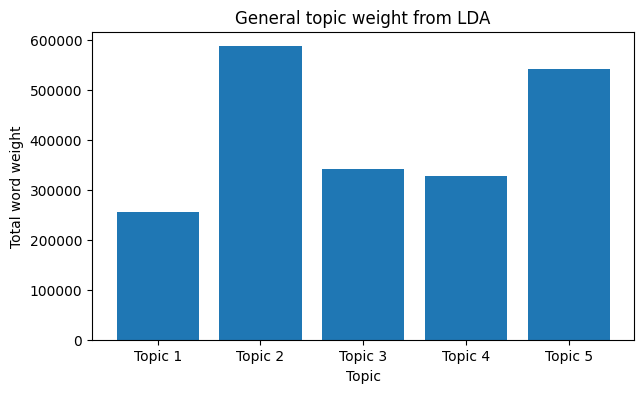

In [37]:
lda_strength = lda_topics.components_.sum(axis=1)

plt.figure(figsize=(7, 4))
plt.bar([f"Topic {i}" for i in range(1, 6)], lda_strength)
plt.title("General topic weight from LDA")
plt.xlabel("Topic")
plt.ylabel("Total word weight")
plt.show()

### Short discussion

The dataset was cleaned and prepared for NLP analysis.

- CountVectorizer was used for word frequency representation.
- TF-IDF was used to identify more relevant terms.
- LDA extracted general topic structures.
- NMF generated more focused topic groups.

Both models identified recurring complaint themes related to financial products, payments, accounts, and credit issues.

In [38]:
!pip install gensim -q

from gensim.corpora import Dictionary
from gensim.models import CoherenceModel

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 5.1 MB/s eta 0:00:00


In [39]:
evaluation_texts = (
    complaints["clean_complaint"]
    .head(5000)
    .apply(str.split)
    .tolist()
)

dictionary = Dictionary(evaluation_texts)

print("Documents for coherence:", len(evaluation_texts))

Documents for coherence: 5000


In [40]:
def get_topic_keywords(model, vocabulary, top_n=10):
    topics = []

    for topic in model.components_:
        top_indexes = topic.argsort()[-top_n:][::-1]
        words = [vocabulary[i] for i in top_indexes]
        topics.append(words)

    return topics


lda_keywords = get_topic_keywords(
    lda_topics,
    count_vocabulary,
    top_n=10
)

nmf_keywords = get_topic_keywords(
    nmf_topics,
    tfidf_vocabulary,
    top_n=10
)

In [41]:
lda_coherence_model = CoherenceModel(
    topics=lda_keywords,
    texts=evaluation_texts,
    dictionary=dictionary,
    coherence="c_v"
)

nmf_coherence_model = CoherenceModel(
    topics=nmf_keywords,
    texts=evaluation_texts,
    dictionary=dictionary,
    coherence="c_v"
)

lda_score = lda_coherence_model.get_coherence()
nmf_score = nmf_coherence_model.get_coherence()

print("LDA coherence score:", round(lda_score, 3))
print("NMF coherence score:", round(nmf_score, 3))

LDA coherence score: 0.625
NMF coherence score: 0.71


In [42]:
lda_topic_scores = lda_coherence_model.get_coherence_per_topic()
nmf_topic_scores = nmf_coherence_model.get_coherence_per_topic()

topic_overview = []

for i in range(5):
    topic_overview.append({
        "Model": "LDA",
        "Topic": i + 1,
        "Top 10 Keywords": ", ".join(lda_keywords[i]),
        "Coherence": round(lda_topic_scores[i], 3)
    })

for i in range(5):
    topic_overview.append({
        "Model": "NMF",
        "Topic": i + 1,
        "Top 10 Keywords": ", ".join(nmf_keywords[i]),
        "Coherence": round(nmf_topic_scores[i], 3)
    })

topic_overview_df = pd.DataFrame(topic_overview)

topic_overview_df

,Model,Topic,Top 10 Keywords,Coherence
0,LDA,1,"payment, loan, credit, late, paid, mortgage, a...",0.561
1,LDA,2,"account, bank, card, told, would, called, call...",0.672
2,LDA,3,"debt, information, consumer, collection, compa...",0.552
3,LDA,4,"account, consumer, section, reporting, right, ...",0.792
4,LDA,5,"credit, report, account, information, reportin...",0.550
5,NMF,1,"section, state, right, reporting, account, vio...",0.840
6,NMF,2,"report, credit, information, consumer, account...",0.667
7,NMF,3,"payment, account, bank, card, loan, would, tol...",0.604
8,NMF,4,"score, transunion, fico, low, attempting, debt...",0.824
9,NMF,5,"balance, xxxxxxxx, theft, identity, opened, it...",0.616


In [44]:
print("Final model comparison:")

if lda_score > nmf_score:
    print("LDA achieved higher overall coherence score.")
elif nmf_score > lda_score:
    print("NMF achieved higher overall coherence score.")
else:
    print("Both models achieved the same overall coherence score.")

print("Topic quality was evaluate using coherence scores and top 10 keywords.")

Final model comparison:
NMF achieved higher overall coherence score.
Topic quality was evaluate using coherence scores and top 10 keywords.


### Topic Evaluation

Topic quality was evaluated using the top 10 keywords and C_v coherence score. Coherence scores were used to compare topic consistency between LDA and NMF. NMF achieved a higher overall coherence score which indicates more consistent topic groups